In [1]:
import numpy as np
import matplotlib.pyplot as plt


def read_latency_data(file_path, ignore):
    with open(file_path, "r") as file:
        latencies = [int(line.strip()) for line in file if line.strip().isdigit()]
    n_ignore = int(len(latencies) * ignore)
    latencies = latencies[n_ignore:]
    return latencies


def get_pctl(data, pctl):
    data = np.sort(data)
    tail = np.percentile(data, pctl).astype(int)
    return tail

In [3]:
# rps_values = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000]
# rps_values = [1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000]
# rps_values = [1500, 1600, 1700, 1800, 1900, 2000]

rps_values = list(range(700, 2001, 50))

datas: dict = {}

for pctl in [99]:
    data = {
        "rps": [],
        "fcfs": [],
        "masa": [],
        "relative": [],
    }
    for rps in rps_values:
        data["rps"].append(rps)

        file_path = f"r{rps}-fcfs.csv"
        tail = get_pctl(read_latency_data(file_path, ignore=0.2), pctl)
        data["fcfs"].append(tail)

        file_path = f"r{rps}-masa.csv"
        tail = get_pctl(read_latency_data(file_path, ignore=0.2), pctl)
        data["masa"].append(tail)

        data["relative"].append((data["fcfs"][-1] - data["masa"][-1]) / data["fcfs"][-1] * 100)
    datas[pctl] = data

print(datas)

{99: {'rps': [700, 750, 800, 850, 900, 950, 1000, 1050, 1100, 1150, 1200, 1250, 1300, 1350, 1400, 1450, 1500, 1550, 1600, 1650, 1700, 1750, 1800, 1850, 1900, 1950, 2000], 'fcfs': [95287, 100042, 104671, 110228, 114311, 121289, 127431, 136537, 142378, 153208, 163280, 174766, 185609, 200168, 217926, 237222, 259204, 302107, 333908, 384123, 446252, 538921, 661797, 837415, 1441700, 1601579, 1557073], 'masa': [89108, 92539, 95623, 100586, 103043, 108565, 112230, 118597, 124799, 131354, 139533, 146431, 154908, 168299, 181274, 195962, 216458, 247746, 269823, 307285, 366208, 456660, 547061, 684369, 1073904, 1230922, 1299423], 'relative': [6.484620147554231, 7.499850062973551, 8.644228105205835, 8.747323728998078, 9.85731906815617, 10.490646307579418, 11.928808531675966, 13.139295575558274, 12.346710868252117, 14.26426818442901, 14.5437285644292, 16.213107812732453, 16.540684988335695, 15.921126253946685, 16.818553086827638, 17.39299053207544, 16.49125785095909, 17.993955783877897, 19.1924122812

100000 753 858 1.139
110000 856 968 1.131
120000 940 1061 1.129
130000 1013 1142 1.127
140000 1078 1215 1.127
150000 1137 1282 1.128
160000 1191 1344 1.128
170000 1242 1402 1.129
180000 1291 1457 1.129
190000 1336 1510 1.130


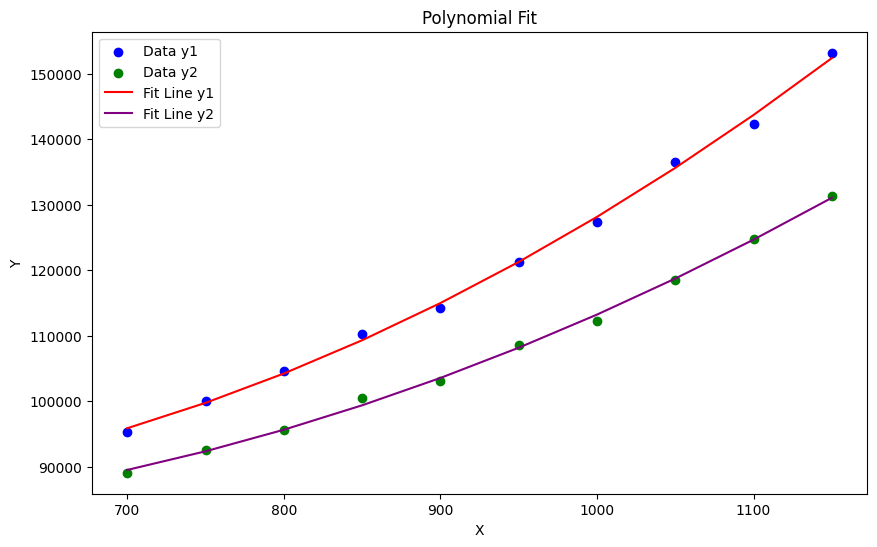

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

data = datas[99]
n_points = 10
x = np.array(data["rps"][:n_points])
y1 = np.array(data["fcfs"][:n_points])
y2 = np.array(data["masa"][:n_points])

degree = 2
coeffs_y1 = np.polyfit(x, y1, degree)
coeffs_y2 = np.polyfit(x, y2, degree)

# Creating polynomial equations using the coefficients
p_y1 = np.poly1d(coeffs_y1)
p_y2 = np.poly1d(coeffs_y2)

def solve(p, target):
    return fsolve(lambda x: p(x) - target, np.mean(x))

targets = [x * int(1e4) for x in range(10, 20)]
for target in targets:
    x1 = round(solve(p_y1, target)[0])
    x2 = round(solve(p_y2, target)[0])
    ratio = x2 / x1
    print(target, x1, x2, f"{ratio:.3f}")

# Generating y-values for the fitted curves
y1_fit = p_y1(x.ravel())
y2_fit = p_y2(x.ravel())

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(x, y1, color="blue", label="Data y1")
plt.scatter(x, y2, color="green", label="Data y2")
plt.plot(x, y1_fit, color="red", label="Fit Line y1")
plt.plot(x, y2_fit, color="purple", label="Fit Line y2")
plt.title("Polynomial Fit")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

In [6]:
import pandas as pd

for pctl in [90, 95, 99, 99.9]:
    data = datas[pctl]
    data["decrease"] = data["relative"]
    data["improve"] = [1.0 / (1.0 - x / 100) for x in data["relative"]]

    data["decrease"] = [f"{round(x, 2)}%" for x in data["decrease"]]
    data["improve"] = [f"{round(x, 2)}%" for x in data["improve"]]

    df = pd.DataFrame(data)
    df = df[["rps", "decrease", "improve"]]
    print(f"tail: {pctl}%")
    print(df)
    print()

tail: 90%
     rps decrease improve
0   1100    6.29%   1.07%
1   1150    7.31%   1.08%
2   1200    7.79%   1.08%
3   1250    8.53%   1.09%
4   1300    9.17%    1.1%
5   1350    9.32%    1.1%
6   1400    9.71%   1.11%
7   1450   10.69%   1.12%
8   1500   10.49%   1.12%
9   1550   12.09%   1.14%
10  1600   12.17%   1.14%
11  1650   11.85%   1.13%
12  1700   12.16%   1.14%
13  1750   11.16%   1.13%
14  1800   13.29%   1.15%
15  1850   14.12%   1.16%
16  1900    13.9%   1.16%
17  1950   15.69%   1.19%
18  2000   13.17%   1.15%

tail: 95%
     rps decrease improve
0   1100    8.65%   1.09%
1   1150    9.95%   1.11%
2   1200   10.59%   1.12%
3   1250   11.32%   1.13%
4   1300   12.22%   1.14%
5   1350   12.08%   1.14%
6   1400   12.52%   1.14%
7   1450   13.93%   1.16%
8   1500   13.39%   1.15%
9   1550    15.0%   1.18%
10  1600   15.19%   1.18%
11  1650   14.87%   1.17%
12  1700   14.57%   1.17%
13  1750   13.94%   1.16%
14  1800   16.09%   1.19%
15  1850   16.22%   1.19%
16  1900   18.41%

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["font.family"] = "Roboto"

plt.rcParams.update(
    {
        "font.size": 20,  # Sets the base default font size
        "axes.labelsize": 20,  # Font size for x and y labels
        "axes.titlesize": 20,  # Font size for plot title
        "xtick.labelsize": 20,  # Font size for x-axis tick labels
        "ytick.labelsize": 20,  # Font size for y-axis tick labels
        "legend.fontsize": 20,  # Font size for legend
    }
)

data = raw

for key in ["fcfs", "masa"]:
    data[key] = [x / 1e3 for x in data[key]]

data["diff"] = []
for i in range(len(data["rps"])):
    data["diff"].append(data["masa"][i] - data["fcfs"][i])

print(data)

# print(data)

# Setting the positions of the bars on the x-axis
x = np.arange(len(data["rps"]))  # the label locations
width = 0.3  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(
    x - width / 2,
    data["fcfs"],
    width,
    label="FCFS",
    color="#C25759",
)
rects2 = ax.bar(
    x + width / 2,
    data["masa"],
    width,
    label="Masa",
    color="#599CB4",
)

# Annotate the bars with the diff
# for i, diff in enumerate(data["diff"]):
#     if diff > 0:
#         text = f"+{diff:.1f}"
#     else:
#         text = f"{diff:.1f}"
#     ax.text(
#         x[i] + width / 2,
#         max(data["fcfs"][i], data["masa"][i]) + 0.2,
#         text,
#         ha="center",
#         va="bottom",
#         color="black",
#         fontsize=18,
#     )

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_title("Elapse = 0")
ax.set_xlabel("RPS")
ax.set_ylabel("P99 Latency (ms)")
# ax.set_ylim(0, 40)
ax.set_xticks(x)
ax.set_xticklabels(data["rps"])
ax.legend()

fig.tight_layout()
plt.savefig("ex0.pdf")
plt.show()